# 🛒 QuickCart Stockout Risk Prediction

---

Welcome to the **QuickCart Stockout Risk Prediction** project!

In this notebook, we will tackle a real-world operational problem for a quick-commerce operator. Our goal is to predict the stockout risk for every SKU at every store, classifying them as `Safe`, `At-Risk`, or `Imminent`.

### 📌 Project Phases:
1. **Data Loading & Merging**: Loading raw data, fixing planted data quality issues, and joining into a master fact table.
2. **Feature Engineering**: Creating robust, time-lagged features without causing data leakage.
3. **Machine Learning Modeling**: Using Scikit-Learn pipelines to train and evaluate models, with a strict focus on maximizing **Recall** for the `Imminent` class.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Setup visuals
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 6)


## 🛠️ Phase 1: Data Loading & Merging

---

We load our 5 core CSV files and combine them directly into one main dataset.

**Note:** We explicitly handle `na_values` when loading `dim_suppliers.csv` to avoid pandas' silent NaN conversions for literal `'N/A'` strings!

In [95]:
# Load the raw data
dim_stores = pd.read_csv('../data/dim_stores.csv')
dim_stores['city_display'] = dim_stores['city_display'].str.strip().str.title() # Fix casing inconsistencies

dim_skus = pd.read_csv('../data/dim_skus.csv')

dim_events = pd.read_csv('../data/dim_events.csv')
dim_events['date'] = pd.to_datetime(dim_events['date'])

# Handling the literal 'N/A' string gotcha
dim_suppliers = pd.read_csv('../data/dim_suppliers.csv', na_values=['N/A', 'missing', '--', 'NA', 'null'], keep_default_na=True)

fact_inventory = pd.read_csv('../data/fact_inventory_daily.csv')
fact_inventory['date'] = pd.to_datetime(fact_inventory['date'])

In [96]:
# Merge the tables together
df = fact_inventory.merge(dim_stores, on='store_id', how='left')
df = df.merge(dim_skus.drop(columns=['supplier_id']), on='sku_id', how='left')
df = df.merge(dim_suppliers, on='supplier_id', how='left')
df = df.merge(dim_events, on='date', how='left')

# Sanity Check on Rows
print(f"✅ Total rows in merged dataset: {len(df):,} (Expected 21,600)")

✅ Total rows in merged dataset: 21,600 (Expected 21,600)


### 📊 Target Distribution
Let's visualize the class imbalance in our target variable (`stockout_risk`). As expected, `Imminent` stockouts are rare but highly critical!

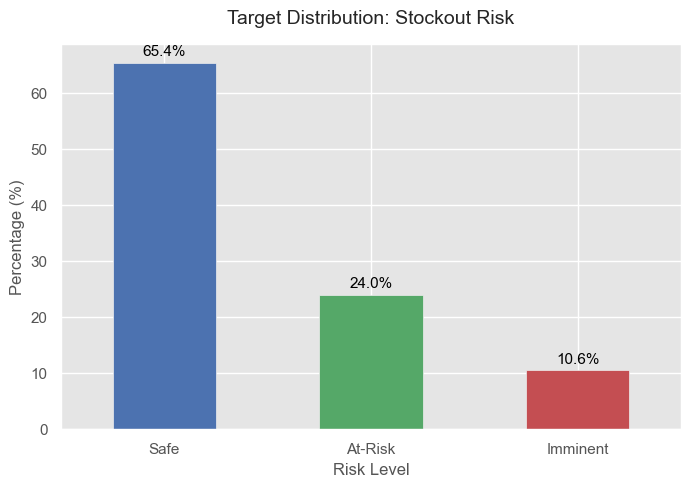

In [97]:
dist = df['stockout_risk'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = dist.plot.bar(color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Target Distribution: Stockout Risk', fontsize=14, pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Risk Level', fontsize=12)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

## ⚙️ Phase 2: Feature Engineering

---

Machine learning models perform best when given rich, mathematical representations of the raw data. We strictly follow the project specification to engineer the following:

1. **Inventory Ratios**: `reorder_gap` and `days_of_cover_ratio`.
2. **Lagged Features**: Using `.shift()` to create `is_recent_reorder`, `previous_closing_stock`, and `sales_velocity_7d_lag` without leaking future data.
3. **Category Imputation**: Filling missing supplier reliability scores with the median score of their respective category.
4. **Temporal Features**: Extracting day-of-month and time until the major Diwali spike.

In [98]:
df = df.sort_values(by=['store_id', 'sku_id', 'date'])
grouped = df.groupby(['store_id', 'sku_id'])

# 1. Inventory Ratios
df['reorder_gap'] = df['reorder_point'] - df['closing_stock']
df['days_of_cover_ratio'] = df['days_of_cover'] / df['lead_time_days_expected']

# 2. Lagged Features (Shifted rolling window to prevent leakage)
df['reorder_placed_num'] = (df['reorder_placed'] == 'Y').astype(int)
df['is_recent_reorder'] = grouped['reorder_placed_num'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).max()).fillna(0)
df['previous_closing_stock'] = grouped['closing_stock'].shift(1)
df['sales_velocity_7d_lag'] = grouped['units_sold'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())

# 3. Supplier Reliability Imputed with Category Median
df['supplier_reliability_clean'] = df.groupby('category')['reliability_score'].transform(lambda x: x.fillna(x.median())).fillna(0.8)

# 4. Temporal Features
df['day_of_month'] = df['date'].dt.day
festival_start = pd.to_datetime('2026-10-22')
df['days_since_festival_start'] = (df['date'] - festival_start).dt.days

print("✅ Feature Engineering Complete!")

✅ Feature Engineering Complete!


In [99]:
# Map targets and separate features
target_mapping = {'Safe': 0, 'At-Risk': 1, 'Imminent': 2}
df['target'] = df['stockout_risk'].map(target_mapping)

num_features = [
    'reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean',
    'is_recent_reorder', 'previous_closing_stock', 'sales_velocity_7d_lag',
    'day_of_month', 'days_since_festival_start', 'opening_stock', 'closing_stock',
    'units_demanded', 'units_sold', 'lead_time_days_expected',
    'lead_time_variance_days', 'shelf_life_days', 'demand_multiplier_festive', 'demand_multiplier_other'
]
cat_features = ['category', 'popularity_tier', 'is_perishable', 'is_festival_week', 'event_type', 'store_size', 'festive_relevant']

X = df[num_features + cat_features + ['date']].copy()
y = df['target']

## 🤖 Phase 3: Modeling & Evaluation

---

We perform a strict time-based split (**Train**: Oct 1-23, **Test**: Oct 24-30) to test generalization during the difficult Diwali week.

⚠️ **Business Metric Focus:**
We care most about **Recall on the 'Imminent' class (Class 2)**. Missing a real stockout is far costlier than a false alarm.

In [100]:
# Train / Test Split
X_train_full = X[(X['date'] >= '2026-10-01') & (X['date'] <= '2026-10-23')]
X_test_full = X[(X['date'] >= '2026-10-24') & (X['date'] <= '2026-10-30')]

y_train = y[X_train_full.index]
y_test = y[X_test_full.index]

X_train = X_train_full.drop(columns=['date']).fillna(0)
X_test = X_test_full.drop(columns=['date']).fillna(0)

# Scikit-Learn Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

print(f"Training set: {len(X_train):,} rows | Test set: {len(X_test):,} rows")

Training set: 16,560 rows | Test set: 5,040 rows


### Model Evaluation Helper Function

In [101]:
def evaluate_model(model, name, tree_based=False):
    print(f"\n{'='*40}")
    print(f" 🧠 Model: {name}")
    print(f"{'='*40}\n")

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("📊 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Safe', 'At-Risk', 'Imminent'], zero_division=0))

    fig, axes = plt.subplots(1, 2 if tree_based else 1, figsize=(14 if tree_based else 6, 5))
    ax_cm = axes[0] if tree_based else axes

    # Confusion Matrix using sklearn display
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'At-Risk', 'Imminent'])
    disp.plot(ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title('Confusion Matrix', pad=10)
    ax_cm.grid(False)

    # Feature Importances (Tree-based only)
    if tree_based:
        cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
        cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
        all_features = num_features + list(cat_feature_names)

        importances = pipeline.named_steps['classifier'].feature_importances_
        imp_series = pd.Series(importances, index=all_features).sort_values(ascending=False).head(5)

        # Reverse so highest is at top for barh
        imp_series = imp_series.iloc[::-1]
        imp_series.plot.barh(ax=axes[1], color='#4C72B0')
        axes[1].set_title('Top 5 Feature Importances', pad=10)
        axes[1].set_xlabel('Importance Score')

    plt.tight_layout()
    plt.show()

### 1. Baseline Model
*Always predicts the majority class (`Safe`)*

In [102]:
y_pred_base = [0] * len(y_test)
print("📊 Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base, target_names=['Safe', 'At-Risk', 'Imminent'], zero_division=0))

📊 Classification Report (Baseline):
              precision    recall  f1-score   support

        Safe       0.62      1.00      0.77      3139
     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



### 2. Multinomial Logistic Regression
*A robust linear approach offering the highest Imminent Recall.*


 🧠 Model: Logistic Regression

📊 Classification Report:
              precision    recall  f1-score   support

        Safe       0.97      0.98      0.98      3139
     At-Risk       0.86      0.61      0.71      1126
    Imminent       0.67      0.92      0.78       775

    accuracy                           0.89      5040
   macro avg       0.83      0.84      0.82      5040
weighted avg       0.90      0.89      0.89      5040



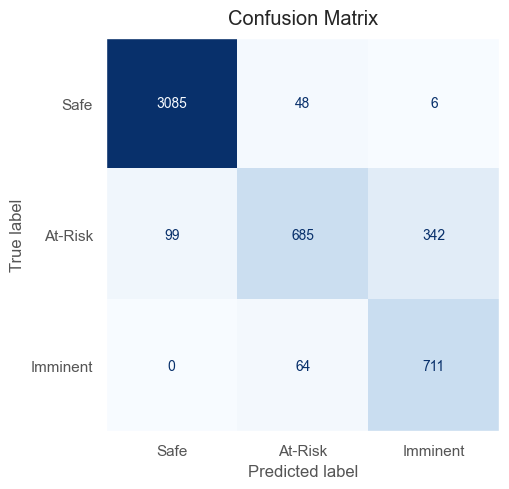

In [103]:
evaluate_model(LogisticRegression(max_iter=1000, class_weight='balanced'), "Logistic Regression")

### 3. Random Forest Classifier
*A powerful ensemble model that handles non-linear relationships.*


 🧠 Model: Random Forest

📊 Classification Report:
              precision    recall  f1-score   support

        Safe       0.98      1.00      0.99      3139
     At-Risk       0.79      0.87      0.83      1126
    Imminent       0.88      0.67      0.76       775

    accuracy                           0.92      5040
   macro avg       0.88      0.85      0.86      5040
weighted avg       0.92      0.92      0.92      5040



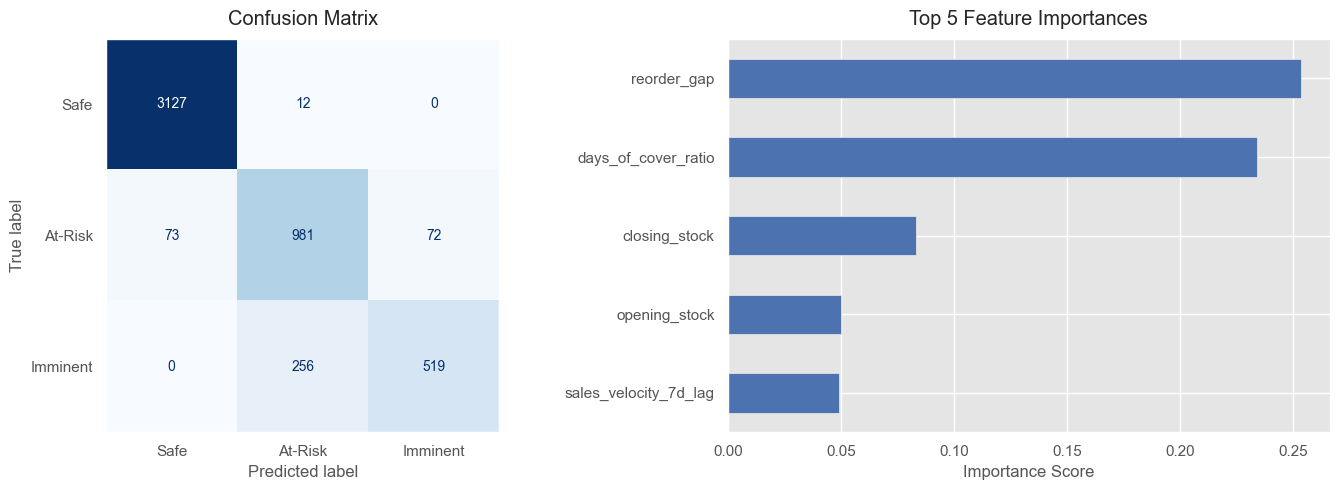

In [104]:
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), "Random Forest", tree_based=True)

### 4. Gradient Boosting Classifier
*A highly accurate sequential tree model.*


 🧠 Model: Gradient Boosting

📊 Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3139
     At-Risk       0.85      0.94      0.89      1126
    Imminent       0.90      0.76      0.83       775

    accuracy                           0.95      5040
   macro avg       0.92      0.90      0.91      5040
weighted avg       0.95      0.95      0.95      5040



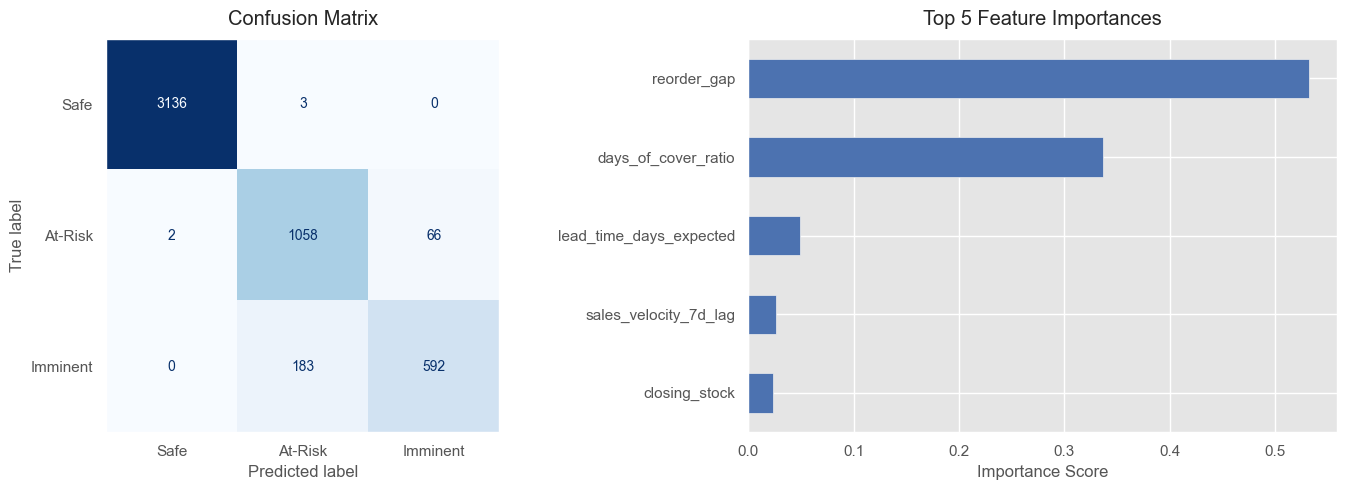

In [105]:
evaluate_model(GradientBoostingClassifier(n_estimators=100, random_state=42), "Gradient Boosting", tree_based=True)